# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [5]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [6]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


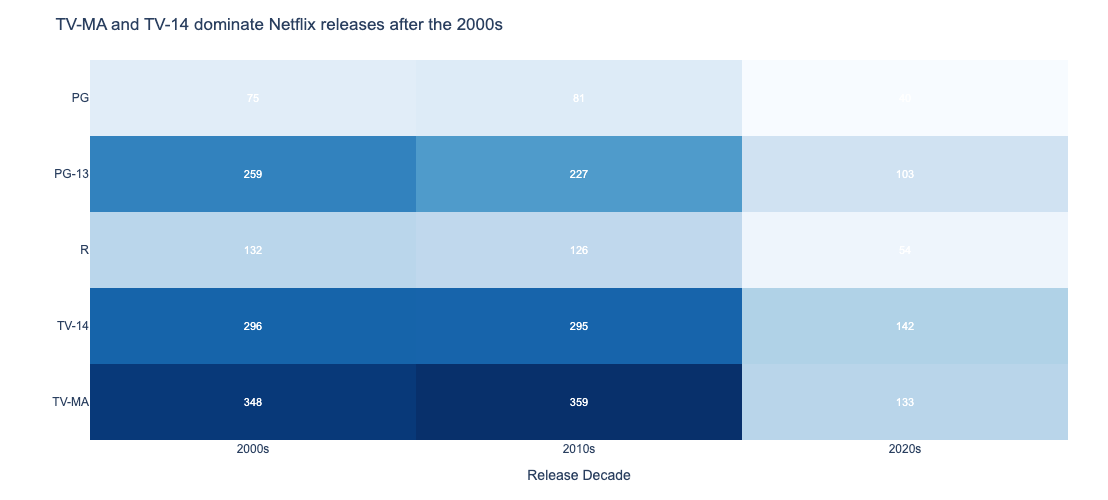

In [7]:
# Task 1
# YOUR CODE HERE

import plotly.express as px

# Create decade column
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Keep only the major ratings
main_ratings = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']

filtered = df.loc[df['rating'].isin(main_ratings)].copy()

# Aggregate counts
rating_decade = (
    filtered
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)

# Build heatmap matrix
pivot = (
    rating_decade
    .pivot(index='rating', columns='decade', values='count')
    .fillna(0)
)

# Optional: order rows manually for readability
rating_order = ['PG', 'PG-13', 'R', 'TV-14', 'TV-MA']
pivot = pivot.reindex(rating_order)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale='Blues',   # sequential scale for count data
    aspect='auto',
    labels={'color': 'Titles'},
    width=950,
    height=500
)

# ── Styling ───────────────────────────────────────────────────────────────────
fig.update_traces(
    textfont=dict(size=11, color='white'),
    hovertemplate='<b>%{y}</b> — %{x}<br>Titles: %{z}<extra></extra>'
)

fig.update_layout(
    title='TV-MA and TV-14 dominate Netflix releases after the 2000s',
    font=dict(family='Arial', size=12),
    coloraxis_showscale=False,
    margin=dict(l=90, r=40, t=60, b=60),
    xaxis=dict(title='Release Decade'),
    yaxis=dict(title='')
)

fig.show()


## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


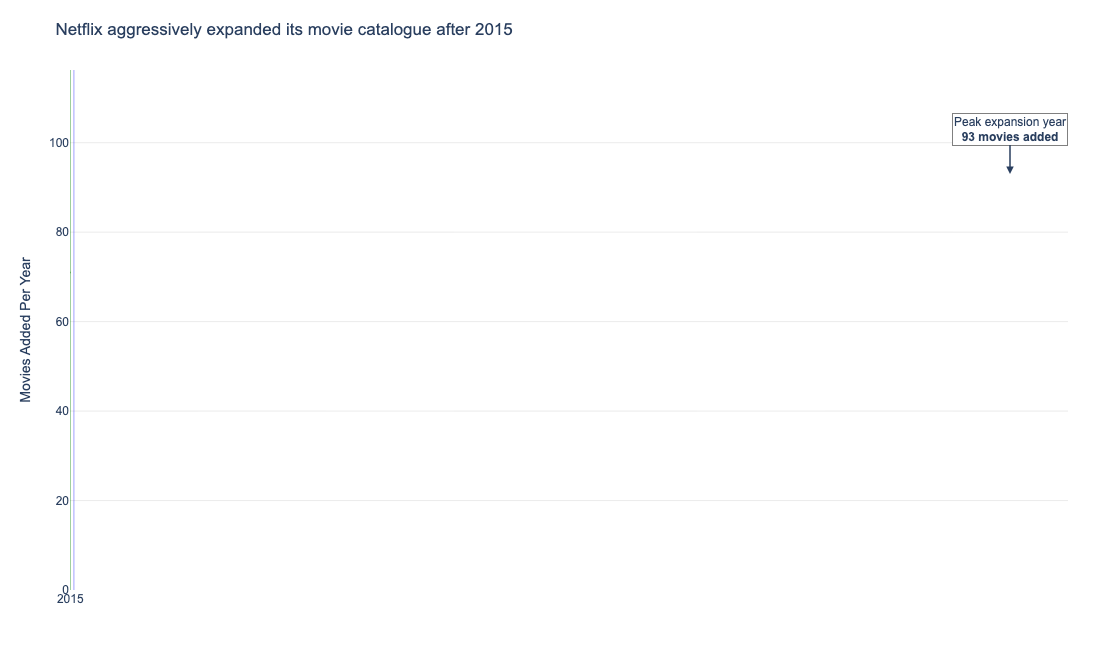

In [10]:
# ── Improved Waterfall Chart: Netflix Movie Growth (2015–2022) ──────────────

import plotly.graph_objects as go

# Filter to Movies only
movies = df.loc[df['type'] == 'Movie'].copy()

# Count movies added each year
adds = (
    movies
    .groupby('added_year')
    .size()
    .reset_index(name='new_titles')
)

# Keep only 2015–2022
adds = adds.loc[
    (adds['added_year'] >= 2015) &
    (adds['added_year'] <= 2022)
].copy()

# Sort by year
adds = adds.sort_values('added_year')

# Calculate cumulative total
total_movies = adds['new_titles'].sum()

# Find year with largest addition
peak_row = adds.loc[adds['new_titles'].idxmax()]
peak_year = str(peak_row['added_year'])
peak_value = peak_row['new_titles']

# ── Create Waterfall Chart ───────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(
    go.Waterfall(

        x=adds['added_year'].astype(str).tolist() + ['Total'],

        y=adds['new_titles'].tolist() + [total_movies],

        measure=['relative'] * len(adds) + ['total'],

        # Required colours
        increasing=dict(
            marker=dict(color='green')
        ),

        totals=dict(
            marker=dict(color='blue')
        ),

        connector=dict(
            line=dict(
                color='rgba(120,120,120,0.5)',
                width=1.5,
                dash='dot'
            )
        ),

        # Values inside bars
        text=[f'{v:,}' for v in adds['new_titles']] + [f'{total_movies:,}'],
        textposition='inside',

        hovertemplate=
        '<b>%{x}</b><br>' +
        'Movies Added: %{y:,}<extra></extra>'
    )
)

# ── Annotation on Largest Addition Year ─────────────────────────────────────
fig.add_annotation(
    x=peak_year,
    y=peak_value,

    text=f'Peak expansion year<br><b>{peak_value:,} movies added</b>',

    showarrow=True,
    arrowhead=2,
    arrowsize=1,
    arrowwidth=1.5,

    ax=0,
    ay=-45,

    bgcolor='white',
    bordercolor='gray',
    borderwidth=1
)

# ── Layout Styling ───────────────────────────────────────────────────────────
fig.update_layout(

    title='Netflix aggressively expanded its movie catalogue after 2015',

    font=dict(
        family='Arial',
        size=12
    ),

    plot_bgcolor='white',
    paper_bgcolor='white',

    width=1100,
    height=650,

    margin=dict(
        l=70,
        r=40,
        t=70,
        b=60
    ),

    showlegend=False,

    yaxis=dict(
        title='Movies Added Per Year',

        gridcolor='rgba(230,230,230,0.8)',

        zeroline=False,

        # Extra headroom so labels/annotation are visible
        range=[0, adds['new_titles'].max() * 1.25]
    ),

    xaxis=dict(
        title='',
        showgrid=False
    )
)

fig.show()